# Property Scanner: Multimodal AI Valuation System

## 1. Project Overview
**Objective**: Predict property prices in Spanish cities (Madrid, Barcelona, etc.) using a **Multimodal Late-Fusion Model**.

**Key Innovation**: Unlike traditional comparable approaches that only use numbers (sqm, rooms), this system "sees" the property using a **Vision Language Model (VLM)** to extract qualitative features (condition, style, finishes) from images and fuses them with quantitative data.


## 2. System Architecture

The system uses a state-of-the-art **Agentic Pipeline** to transform raw web data into reasoned valuations.

### Pipeline Stages:
1.  **Extraction Agent**: Scrapes and normalizes raw data into `CanonicalListing` objects.
2.  **Vision Agent (VLM)**: Deep-inspects photos using **Llava/Ollama** to describe interiors and finishes.
3.  **Embedding Engine**: Converts text and descriptions into **384D vectors** via SentenceTransformers.
4.  **Fusion Model**: A custom PyTorch model that performs **Cross-Attention** between the target property and local market comparables.


## 3. Data Inspection

Let's look at the data collected in `data/listings.db`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json
import seaborn as sns
import sys
import os

# Ensure we can import from src
sys.path.append('..')

# Connect to Database
conn = sqlite3.connect('../data/listings.db')
df = pd.read_sql_query("SELECT * FROM listings WHERE price > 0", conn)
conn.close()

print(f"Total Listings: {len(df)}")
display(df.head())

Total Listings: 6963


,id,source_id,external_id,url,title,description,price,currency,property_type,bedrooms,...,vlm_description,text_sentiment,image_sentiment,analysis_meta,tags,listed_at,updated_at,fetched_at,status,sold_at
0,37f9b170a30a74d7eb5f3bf0b94bcf5b,pisos,58417153918,https://www.pisos.com/comprar/piso-circular_va...,Piso en venta en Circular-Vadillos,"{\n ""facts"": {\n ""has_elevator"": true,\n ...",2.400000e+05,EUR,apartment,3.0,...,"{""condition"": ""renovated/good"", ""quality"": ""st...",0.7,0.0,"{""facts"": {""has_elevator"": true, ""has_pool"": f...","[""PLUS:87 m\u00b2 \u00fatiles"", ""PLUS:exterior...",2026-01-14 18:29:32.845629,2026-01-14 18:29:16.878300,2026-01-14 18:29:32.845724,active,None
1,61a4cddf89dcc9fc2428c576ab1a4e33,pisos,59264286204,https://www.pisos.com/comprar/piso-paseo_zorri...,Piso en venta en Paseo Zorrilla-Campo Grande-C...,"{\n ""facts"": {\n ""has_elevator"": true,\n ...",1.699000e+05,EUR,apartment,4.0,...,"{""condition"": ""renovated"", ""quality"": ""luxury""...",0.8,0.0,"{""facts"": {""has_elevator"": true, ""has_pool"": f...","[""MINUS:needs reform (1960 construction)"", ""PL...",2026-01-14 18:29:34.377481,2026-01-14 18:29:16.934751,2026-01-14 18:29:34.377559,active,None
2,e472c0052d13e37b51491fdc51fb98cc,pisos,60929728006,https://www.pisos.com/comprar/piso-circular_va...,Piso en venta en Circular-Vadillos,"{\n ""facts"": {\n ""has_elevator"": true,\n ...",1.430000e+05,EUR,apartment,3.0,...,"{""condition"": ""renovated"", ""quality"": ""standar...",-0.2,0.0,"{""facts"": {""has_elevator"": true, ""has_pool"": f...","[""PLUS:gas_calefaction"", ""MINUS:needs_reform"",...",2026-01-14 18:29:50.601528,2026-01-14 18:29:34.597545,2026-01-14 18:29:50.601587,active,None
3,4b62cf843d2ea9e52c18b7d923f43a61,pisos,57544325835,https://www.pisos.com/comprar/piso-valladolid_...,Piso en venta en Calle José Garrote Tebar,"{\n ""facts"": {\n ""has_elevator"": false,\n ...",1.700001e+11,EUR,apartment,2.0,...,"{""condition"": ""Renovated/Good"", ""quality"": ""St...",0.5,0.0,"{""facts"": {""has_elevator"": false, ""has_pool"": ...","[""PLUS:terrace"", ""PLUS:good_location""]",2026-01-14 18:29:52.059022,2026-01-14 18:29:36.080850,2026-01-14 18:29:52.059080,active,None
4,02af7dd79b94bf53aee25f9ad2e5d99e,pisos,54208839719,https://www.pisos.com/comprar/casa_adosada-val...,Casa adosada en venta en Calle Cam. de Zaratán,"{\n ""facts"": {\n ""has_elevator"": false,\n ...",3.099000e+05,EUR,apartment,3.0,...,"{""condition"": ""good/renovated/needs_work"", ""qu...",0.7,0.0,"{""facts"": {""has_elevator"": false, ""has_pool"": ...","[""PLUS:gran estado de conservaci\u00f3n"", ""PLU...",2026-01-14 18:30:09.014756,2026-01-14 18:29:52.294530,2026-01-14 18:30:09.014814,active,None


### 3.1 Market Composition: City Breakdown
Where is our data coming from? We've expanded to include the most active real estate markets in Spain.

/tmp/ipykernel_2573576/3550406612.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




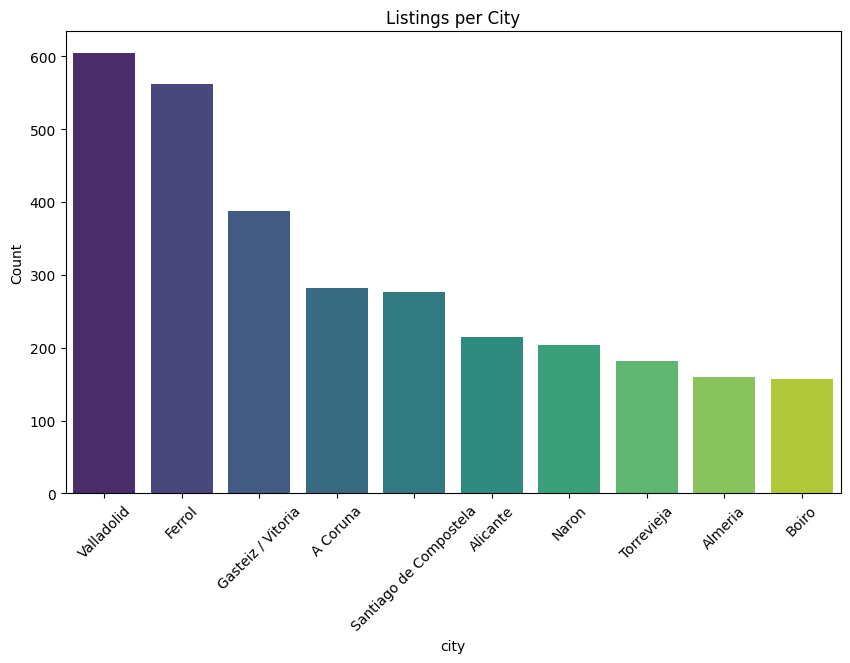

In [8]:
plt.figure(figsize=(10, 6))
city_counts = df['city'].value_counts()[:10]
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')
plt.title('Listings per City')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

### 3.2 Geospatial Analysis
Visualizing the spatial density of our properties.

In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Filter out valid coordinates
geo_df = df[(df['lat'] != 0) & (df['lon'] != 0)]

# Major Cities for Reference
cities_data = {
    'City': ['Madrid', 'Barcelona', 'Valencia', 'Seville', 'Zaragoza', 'Málaga'],
    'Lat': [40.4168, 41.3851, 39.4699, 37.3891, 41.6488, 36.7212],
    'Lon': [-3.7038, 2.1734, -0.3763, -5.9845, -0.8891, -4.4214]
}
cities_df = pd.DataFrame(cities_data)

# Create Plotly Map with Satellite Background (Esri)
fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
                        color_continuous_scale='Viridis', size_max=15, zoom=5, height=600,
                        hover_data=['price', 'city'], title='Property Distribution (Satellite View)')

# Add City Labels
fig.add_trace(go.Scattermapbox(
    lat=cities_df['Lat'],
    lon=cities_df['Lon'],
    mode='markers+text',
    marker=go.scattermapbox.Marker(size=12, color='red'),
    text=cities_df['City'],
    textposition='top right',
    name='Major Cities'
))

# Update layout to use Esri World Imagery (Satellite) tiles
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "Esri, Maxar, Earthstar Geographics",
            "source": [
                "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ]
        }
    ],
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.show()

/tmp/ipykernel_2573576/737516324.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
/tmp/ipykernel_2573576/737516324.py:21: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### 3.3 Data Quality Analysis

Understanding data completeness is crucial. The chart below visualizes the percentage of missing values for each feature in our dataset.

/tmp/ipykernel_2573576/1432240471.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




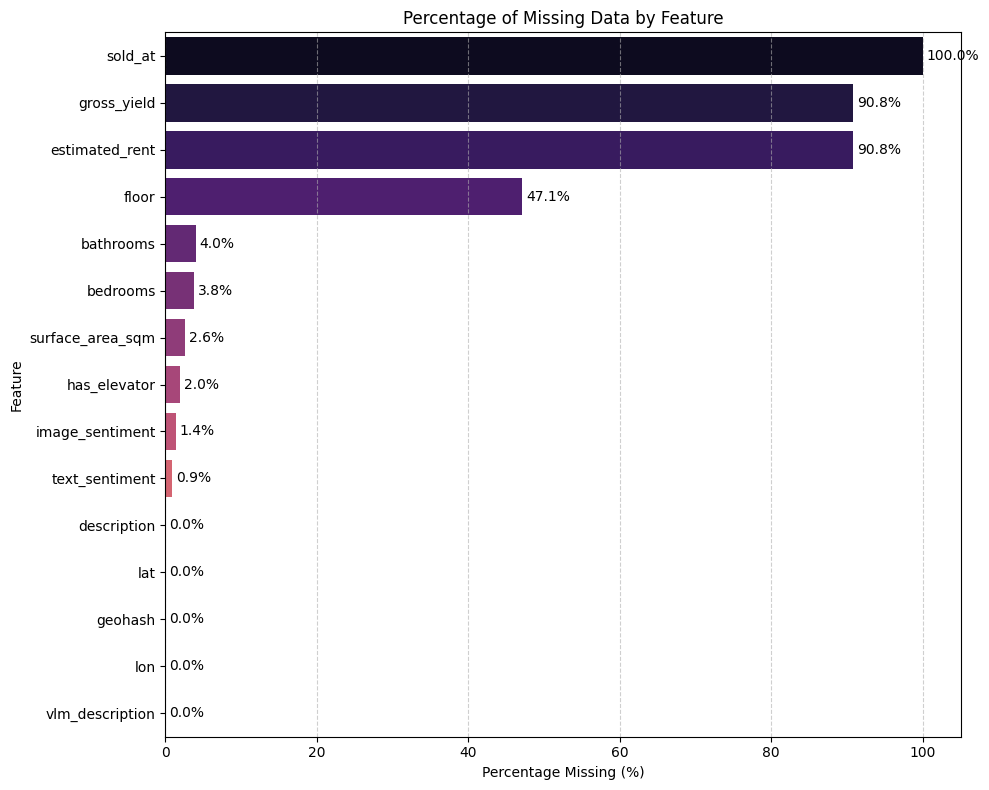

In [4]:
# Connect to Database to get full dataset
conn = sqlite3.connect('../data/listings.db')
quality_df = pd.read_sql_query("SELECT * FROM listings", conn)
conn.close()

# Calculate missing percentages
missing_props = quality_df.isnull().sum() / len(quality_df) * 100
# Filter properties that actually have missing data
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

if not missing_props.empty:
    # Visualize
    plt.figure(figsize=(10, 8))
    sns.barplot(x=missing_props.values, y=missing_props.index, palette='magma')
    plt.title('Percentage of Missing Data by Feature')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Add value labels
    for i, v in enumerate(missing_props.values):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Amazing! No missing data found in the dataset.")

## 4. VLM: The Visual Intelligence

Traditional models miss detail. Our VLM captures descriptions like *"modern open-concept kitchen"* or *"ranch-style villa with pool"*.

In [5]:
vlm_enriched = df[df['vlm_description'].notna() & (df['vlm_description'] != '')]
print(f"Enriched Listings: {len(vlm_enriched)}")

if not vlm_enriched.empty:
    sample = vlm_enriched.sample(1).iloc[0]
    print(f"\nProperty: {sample['title']}")
    print("VLM Insight:", sample['vlm_description'][:400] + "...")

Enriched Listings: 6963

Property: Piso en alquiler en Acequión-Los Naúfragos
VLM Insight: {"condition": "renovated/good", "quality": "luxury", "visual_sentiment": 0.0, "rooms": ["kitchen", "bedroom", "bathroom", "balcony"], "features": ["hardwood floors", "modern kitchen", "large windows", "view", "pool", "terrace"], "summary": "Renovated home with luxury amenities, featuring hardwood flooring, modern kitchen and ample natural light from large windows. The property offers a terrace and...


## 5. Model Training & Performance

Below is the current training convergence for the **92k-parameter compact model**.

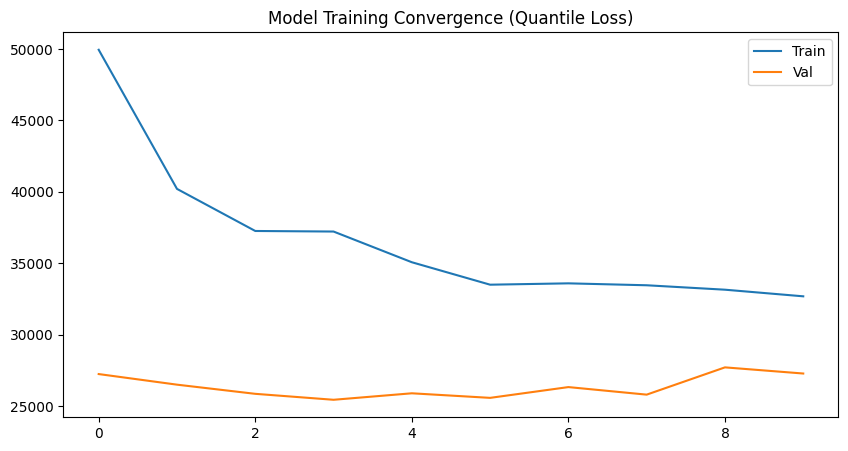

In [6]:
import torch
import matplotlib.pyplot as plt
checkpoint_path = '../models/checkpoint_latest.pt'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    plt.figure(figsize=(10, 5))
    plt.plot(ckpt['train_losses'], label='Train')
    plt.plot(ckpt['val_losses'], label='Val')
    plt.title('Model Training Convergence (Quantile Loss)')
    plt.legend()
    plt.show()
else:
    print("Checkpoint not found. Run training first.")

## 6. Live Inference Example

Compare the AI's valuation with the actual market price.

In [14]:
# Debug: Check data for comp availability
print(f"Total listings: {len(df)}")
print(f"Unique cities: {df['city'].nunique()}")
print(f"Listings with lat/lon: {df[['lat', 'lon']].notna().all(axis=1).sum()}")
print(f"Sample cities: {df['city'].value_counts().head()}")
print(f"Sample lat/lon: {df[['lat', 'lon']].head()}")
if 'listing_type' in df.columns:
    print(f"Listing types: {df['listing_type'].value_counts()}")
else:
    print("No listing_type column")
print(f"Price range: {df['price'].min():.0f} - {df['price'].max():.0f}")

Total listings: 6963
Unique cities: 269
Listings with lat/lon: 6963
Sample cities: city
Valladolid                604
Ferrol                    562
Gasteiz / Vitoria         388
A Coruna                  282
Santiago de Compostela    277
Name: count, dtype: int64
Sample lat/lon:          lat       lon
0  41.647840 -4.717165
1  41.631965 -4.741878
2  41.645489 -4.718594
3  41.633523 -4.756156
4  41.625160 -4.764958
Listing types: listing_type
sale    4402
rent    2561
Name: count, dtype: int64
Price range: 1 - 99000011000010


In [16]:
from src.training.dataset import PropertyDataset, collate_fn
from src.services.fusion_model import PropertyFusionModel
import torch
import numpy as np

# Set up dataset and sample
try:
    ds = PropertyDataset(db_path='../data/listings.db', use_vlm=True, geo_radius_km=50, size_ratio_tolerance=0.5, require_same_property_type=False, num_comps=1, time_safe_comps=False)
    idx = np.random.randint(0, len(ds))
    item = ds[idx]
    batch = collate_fn([item])
    print("Dataset and batch created successfully.")
except ValueError as e:
    print(f"Dataset creation failed: {e}")
    print("Skipping live inference example due to insufficient comparable data.")
    batch = None

# Load Model
model = PropertyFusionModel(hidden_dim=64, num_heads=2) # Compact settings
if os.path.exists('../models/fusion_model.pt'):
    try:
        model.load_state_dict(torch.load('../models/fusion_model.pt', map_location='cpu'))
        model.eval()
        if batch is not None:
            with torch.no_grad():
                q, _, _, _ = model(
                    target_tab=batch['target_tab'], 
                    target_text=batch['target_text'],
                    comp_tab=batch['comp_tab'], 
                    comp_text=batch['comp_text'], 
                    comp_prices=batch['comp_prices'],
                    target_image=None,
                    comp_image=None
                )
                
            actual = batch['target_price'][0].item()
            pred = q[0, 1].item()
            print(f"Title: {ds.listings[idx]['title']}")
            print(f"Actual: €{actual:,.0f} | Predicted: €{pred:,.0f} | Error: {abs(actual-pred)/actual*100:.1f}%")
        else:
            print("Model loaded successfully, but no batch available for prediction.")
    except RuntimeError as e:
        print(f"Model loading failed: {e}. Skipping prediction.")
else:
    print("Model weights not found. Prediction skipped.")

2026-01-16 10:36:31 [info     ] text_encoder_initialized       dim=384 model=all-MiniLM-L6-v2
2026-01-16 10:36:32 [warning  ] outliers_dropped               count=178 max_price=15000000 min_price=10000
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=arroyo
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=arroyo
2026-01-16 10:36:32 [warning  ] hedonic_index_not_found        month=2026-01 region=valladolid
2026-01-16 10:36:32 [warning  ] hedonic_index_

### 3.4 Data Cleaning: Outlier Removal

To ensure data quality, we remove records with values that are physically impossible or highly improbable (e.g., extreme prices, invalid floors).

In [17]:
# Simple Cleaner Logic
original_count = len(df)

# Define sensible bounds for our features
guards = {
    'price': {'min': 10000, 'max': 10000000},
    'floor': {'min': -5, 'max': 70},
    'surface_area_sqm': {'min': 10, 'max': 5000},
    'bedrooms': {'min': 0, 'max': 25},
    'bathrooms': {'min': 0, 'max': 20}
}

print(f"Starting Data Cleaning (Rows: {original_count})...")

# Convert guarded columns to numeric
for col in guards.keys():
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col, bounds in guards.items():
    if col in df.columns:
        # Filter outliers
        mask = (df[col] < bounds['min']) | (df[col] > bounds['max'])
        n_dropped = mask.sum()
        if n_dropped > 0:
            print(f" - Removing {n_dropped} outliers in '{col}' (Allowed: {bounds['min']} - {bounds['max']})")
            df = df[~mask]

print(f"Cleaning Complete. Final Rows: {len(df)} (Total Removed: {original_count - len(df)})")

Starting Data Cleaning (Rows: 6963)...
 - Removing 2685 outliers in 'price' (Allowed: 10000 - 10000000)
 - Removing 210 outliers in 'floor' (Allowed: -5 - 70)
 - Removing 83 outliers in 'surface_area_sqm' (Allowed: 10 - 5000)
 - Removing 2 outliers in 'bedrooms' (Allowed: 0 - 25)
Cleaning Complete. Final Rows: 3983 (Total Removed: 2980)


### 3.5 Feature Distributions

Let's create violin plots for all numerical features to understand their distributions.

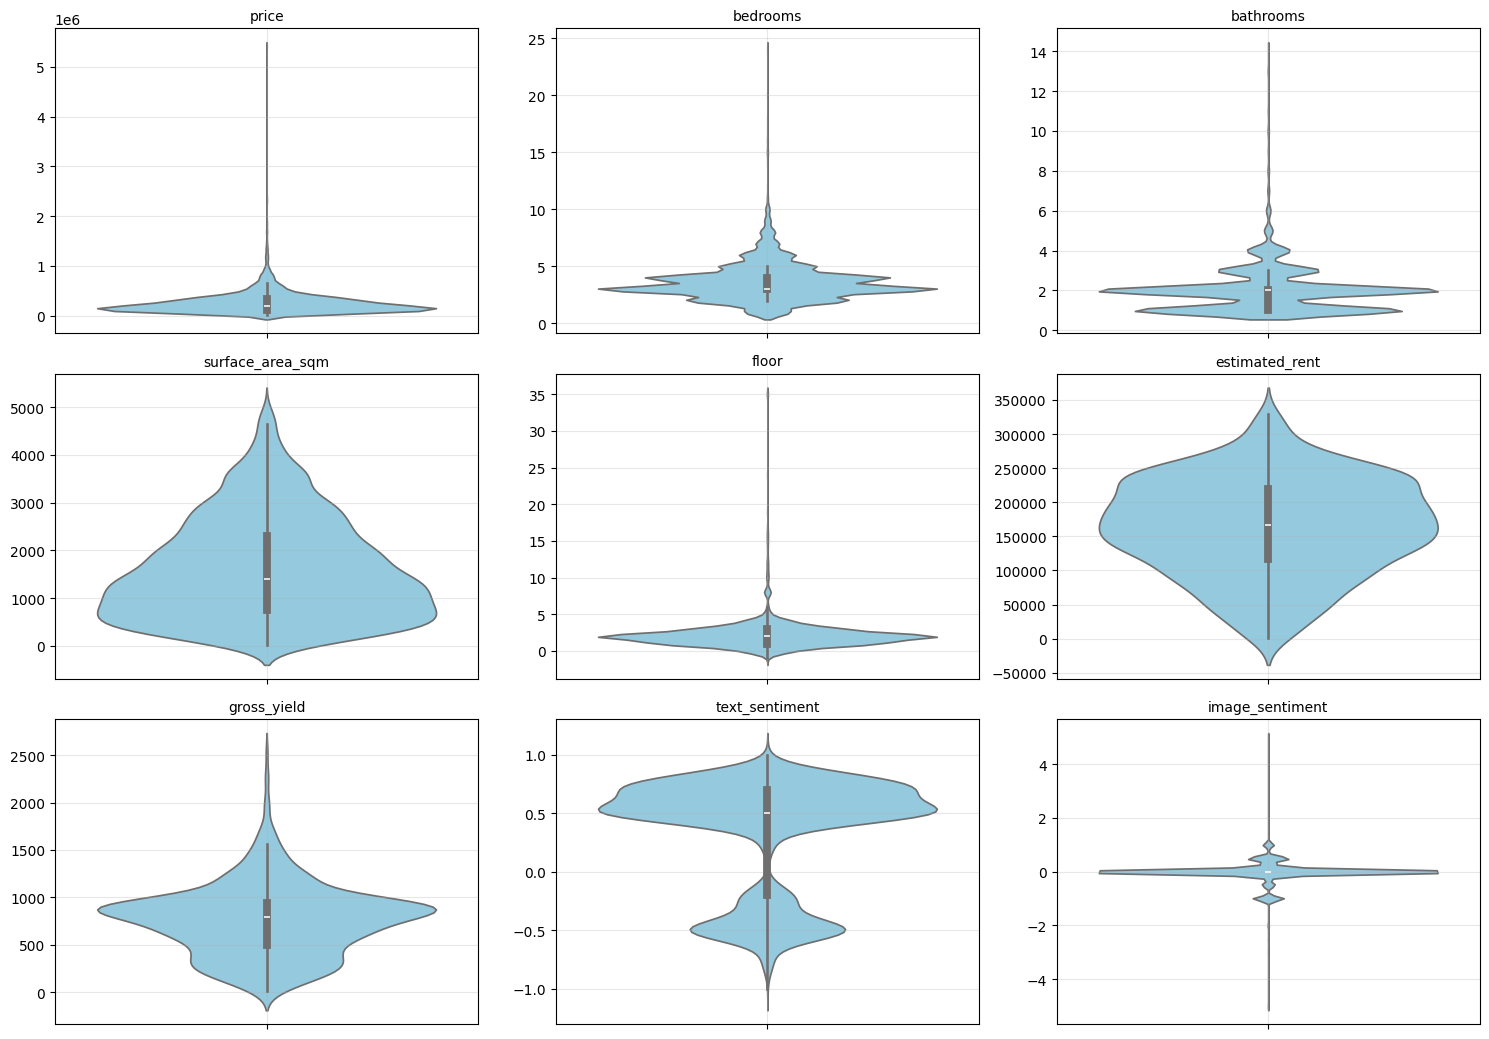

In [18]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Exclude boolean-like or specific columns that don't make sense for violin plots
exclude_cols = ['has_elevator', 'lat', 'lon'] 
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Set up a more compact plotting layout
n_cols = 3  # Increased columns for compactness
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Reduced height multiplier to make it more compact vertically
plt.figure(figsize=(15, 3.5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=10)
    plt.ylabel('') # Remove y-label to save space, usually title is enough
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 VLM Description Coverage
Analysis of how many listings have Vision Language Model descriptions generated from images.


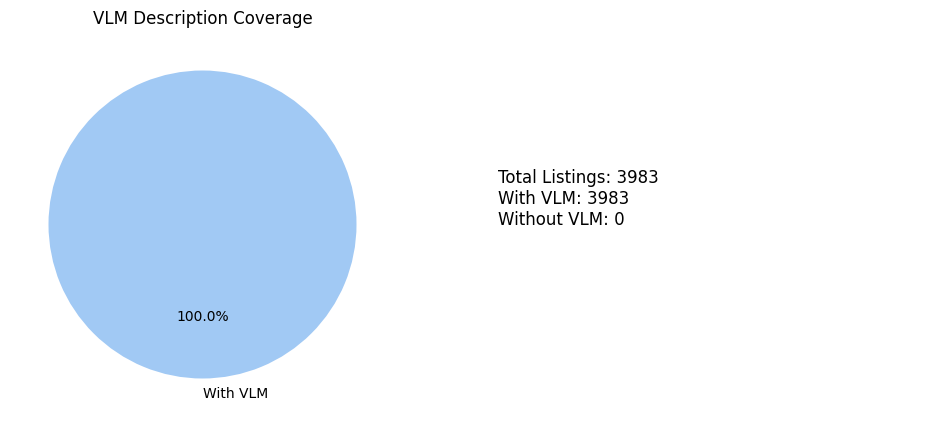


--- 4 Random VLM Description Examples ---

Example 1:
{"condition": "Renovated", "quality": "Luxury", "visual_sentiment": 0.0, "rooms": ["kitchen", "bedroom", "bathroom", "balcony"], "features": ["hardwood_floors", "modern_kitchen", "large_windows", "view", "pool", "terrace"]}...

Example 2:
{"condition": "renovated/good/fair/needs_work",

"quality": ["luxury/standard/basic"],

"visual_sentiment": 0.0,

"rooms": ["kitchen", "bedroom", "bathroom", "balcony"],

"features": ["hardwood_floors", "modern_kitchen", "large_windows", "view", "pool", "terrace"],

"summary": "The grid consists of ...

Example 3:
{"condition": "fair", "quality": "standard", "visual_sentiment": -1.0, "rooms": ["kitchen", "bedroom", "bathroom"], "features": ["large_windows"]}...

Example 4:
{"condition": "Fair", "quality": "Luxury", "visual_sentiment": 0.25, "rooms": ["Kitchen", "Bedroom", "Balcony"], "features": ["Hardwood floors", "Large windows", "Modern kitchen"]}...


In [19]:
# VLM Statistics
vlm_mask = df['vlm_description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
vlm_counts = vlm_mask.value_counts()

# Handle case where only one category exists
if len(vlm_counts) == 2:
    vlm_counts.index = ['With VLM', 'Without VLM'] if vlm_counts.index[0] == True else ['Without VLM', 'With VLM']
elif True in vlm_counts.index:
    vlm_counts.index = ['With VLM']
else:
    vlm_counts.index = ['Without VLM']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[0:len(vlm_counts)]
plt.pie(vlm_counts, labels=vlm_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('VLM Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith VLM: {vlm_mask.sum()}\nWithout VLM: {len(df) - vlm_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random VLM Description Examples ---')
if vlm_mask.sum() > 0:
    for i, desc in enumerate(df[vlm_mask]['vlm_description'].sample(min(4, vlm_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')


### 3.4 Text Description Coverage
Analysis of standard text descriptions provided in the listings.


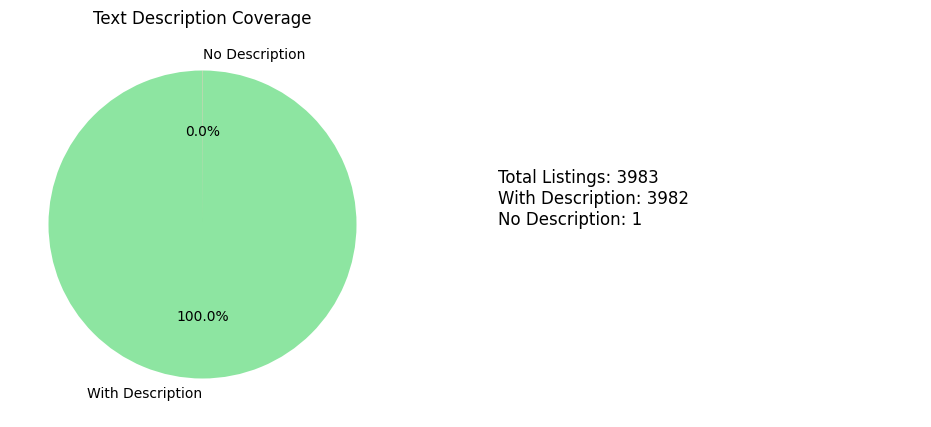


--- 4 Random Text Description Examples ---

Example 1:
{
  "facts": {
    "has_elevator": true,
    "has_pool": false,
    "has_garage": false,
    "renovation_needed": false,
    "floor": 138
  },
  "financial_analysis": {
    "positive_drivers": [
      "central_location",
      "two_large_rooms"
    ],
    "negative_drivers": [],
    "investor_sentim...

Example 2:
{
  "facts": {
    "has_elevator": false,
    "has_pool": false,
    "has_garage": false,
    "renovation_needed": false,
    "floor": 4
  },
  "financial_analysis": {
    "positive_drivers": [
      "proximity to schools",
      "individual heating"
    ],
    "negative_drivers": [
      "old build...

Example 3:
{
  "facts": {
    "has_elevator": false,
    "has_pool": false,
    "has_garage": true,
    "renovation_needed": false,
    "floor": null
  },
  "financial_analysis": {
    "positive_drivers": [
      "generous_plot_size",
      "amplio_salon_comedor"
    ],
    "negative_drivers": [],
    "investo...

Example

In [20]:
# LLM/Text Statistics
text_mask = df['description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
text_counts = text_mask.value_counts()

# Handle case where only one category exists
if len(text_counts) == 2:
    text_counts.index = ['With Description', 'No Description'] if text_counts.index[0] == True else ['No Description', 'With Description']
elif True in text_counts.index:
    text_counts.index = ['With Description']
else:
    text_counts.index = ['No Description']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[2:2+len(text_counts)]
plt.pie(text_counts, labels=text_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Text Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith Description: {text_mask.sum()}\nNo Description: {len(df) - text_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random Text Description Examples ---')
if text_mask.sum() > 0:
    for i, desc in enumerate(df[text_mask]['description'].sample(min(4, text_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')
